# Data loading

In [1]:
# Task 1.1 - Create the cleaned Netflix ratings file when needed
# The conversion is skipped when netflix_cleaned.csv already exists.

from pathlib import Path

input_files = [
    'combined_data_1.txt',
    'combined_data_2.txt',
    'combined_data_3.txt',
    'combined_data_4.txt'
]
cleaned_path = Path('netflix_cleaned.csv')

if cleaned_path.exists():
    print('Using existing cleaned dataset:', cleaned_path)
else:
    with open(cleaned_path, 'w', encoding='utf-8') as output_file:
        output_file.write('user_id,movie_id,rating,date\n')

        for file_name in input_files:
            with open(file_name, 'r', encoding='utf-8') as input_file:
                movie_id = None

                for line in input_file:
                    if line.endswith(':\n'):
                        movie_id = line.strip().replace(':', '')
                    else:
                        user_id, rating, date = line.strip().split(',')
                        output_file.write(f'{user_id},{movie_id},{rating},{date}\n')

    print('Finished converting files.')

Using existing cleaned dataset: netflix_cleaned.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_curve, roc_auc_score,mean_squared_error, mean_absolute_error

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

from warnings import filterwarnings

import joblib

np.random.seed(42)

filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


In [3]:
# Task 1.2 - Load a reproducible user-cohort sample of the cleaned ratings dataset
# 1. Read the large CSV in chunks to avoid loading all rows into memory
# 2. Keep all ratings for about 1% of users so collaborative filtering retains user history

user_sample_modulo = 100
selected_user_remainders = {0}
chunk_size = 500_000
sampled_chunks = []

for chunk in pd.read_csv(
    'netflix_cleaned.csv',
    dtype={
        'user_id': 'int32',
        'movie_id': 'int16',
        'rating': 'int8'
    },
    parse_dates=['date'],
    chunksize=chunk_size
):
    user_cohort_chunk = chunk[
        chunk['user_id'].mod(user_sample_modulo).isin(selected_user_remainders)
    ]
    sampled_chunks.append(user_cohort_chunk)

Movies = pd.concat(sampled_chunks, ignore_index=True)

print('User-cohort ratings shape:', Movies.shape)
print('Unique sampled users:', Movies['user_id'].nunique())
print('Average ratings per sampled user:', round(Movies.groupby('user_id').size().mean(), 2))
Movies.head()

User-cohort ratings shape: (983241, 4)
Unique sampled users: 4805
Average ratings per sampled user: 204.63


,user_id,movie_id,rating,date
0,1196100,1,4,2004-10-30
1,99400,1,5,2005-09-16
2,2607300,1,3,2005-07-25
3,810700,1,5,2004-08-31
4,2279000,1,3,2005-02-18


In [4]:
Movies.head()

,user_id,movie_id,rating,date
0,1196100,1,4,2004-10-30
1,99400,1,5,2005-09-16
2,2607300,1,3,2005-07-25
3,810700,1,5,2004-08-31
4,2279000,1,3,2005-02-18


In [5]:
titles_raw = pd.read_csv(
    "movie_titles.csv",
    encoding="latin1",
    header=None,
    names=["line"],
    sep="\t"
)

titles = titles_raw["line"].str.split(",", n=2, expand=True)
titles.columns = ["movie_id", "year", "title"]

titles["movie_id"] = titles["movie_id"].astype("int16")
titles["year"] = pd.to_numeric(titles["year"], errors="coerce").astype("Int16")
titles["title"] = titles["title"].astype("string")

titles.head()


,movie_id,year,title
0,1,2003,Dinosaur Planet
1,2,2004,Isle of Man TT 2004 Review
2,3,1997,Character
3,4,1994,Paula Abdul's Get Up & Dance
4,5,2004,The Rise and Fall of ECW


In [6]:
df = pd.merge(Movies, titles, on='movie_id', how='inner')

In [7]:
df.head()

,user_id,movie_id,rating,date,year,title
0,1196100,1,4,2004-10-30,2003,Dinosaur Planet
1,99400,1,5,2005-09-16,2003,Dinosaur Planet
2,2607300,1,3,2005-07-25,2003,Dinosaur Planet
3,810700,1,5,2004-08-31,2003,Dinosaur Planet
4,2279000,1,3,2005-02-18,2003,Dinosaur Planet


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 983241 entries, 0 to 983240
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   user_id   983241 non-null  int32         
 1   movie_id  983241 non-null  int16         
 2   rating    983241 non-null  int8          
 3   date      983241 non-null  datetime64[ns]
 4   year      983234 non-null  Int16         
 5   title     983241 non-null  string        
dtypes: Int16(1), datetime64[ns](1), int16(1), int32(1), int8(1), string(1)
memory usage: 24.4 MB


In [9]:
print('Shape:', df.shape)
print(df.columns)

Shape: (983241, 6)
Index(['user_id', 'movie_id', 'rating', 'date', 'year', 'title'], dtype='object')


In [10]:
print(df.isnull().sum())

user_id     0
movie_id    0
rating      0
date        0
year        7
title       0
dtype: int64


In [11]:
print(f"Duplicated rows: {df.duplicated().sum()}")

Duplicated rows: 0


## Sampling

In [12]:
# Task 1.4 - Create the final modeling sample
# The chunked load already produces about one million ratings.

model_sample_size = 1_000_000

if df.shape[0] > model_sample_size:
    netflix_df = df.sample(n=model_sample_size, random_state=42).copy()
else:
    netflix_df = df.copy()

print('Sample shape:', netflix_df.shape)
netflix_df.head()

Sample shape: (983241, 6)


,user_id,movie_id,rating,date,year,title
0,1196100,1,4,2004-10-30,2003,Dinosaur Planet
1,99400,1,5,2005-09-16,2003,Dinosaur Planet
2,2607300,1,3,2005-07-25,2003,Dinosaur Planet
3,810700,1,5,2004-08-31,2003,Dinosaur Planet
4,2279000,1,3,2005-02-18,2003,Dinosaur Planet


user_id     0
movie_id    0
rating      0
date        0
year        7
title       0
dtype: int64


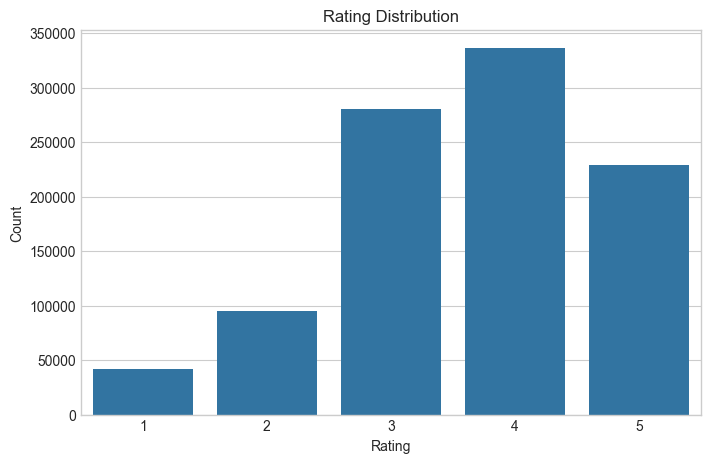

In [13]:
print(netflix_df.isnull().sum())

plt.figure(figsize=(8, 5))
sns.countplot(data=netflix_df, x='rating')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [14]:
# Task 1.5 - Drop unnecessary columns
# 1. Drop date and year because they are not needed for the baseline model
# 2. Keep user_id, movie_id, rating, and title

netflix_df = netflix_df.drop(columns=['date', 'year'], errors='ignore').copy()

print('Modeling dataframe shape:', netflix_df.shape)
netflix_df.head()


Modeling dataframe shape: (983241, 4)


,user_id,movie_id,rating,title
0,1196100,1,4,Dinosaur Planet
1,99400,1,5,Dinosaur Planet
2,2607300,1,3,Dinosaur Planet
3,810700,1,5,Dinosaur Planet
4,2279000,1,3,Dinosaur Planet


# Exploratory Data Analysis After Cleaning

These cells analyze the cleaned modeling sample before training the recommender model.


In [15]:
# Task 1.6 - Inspect cleaned modeling data
# Display: shape, data types, unique values, and missing values

print('Cleaned sample shape:', netflix_df.shape)

dtypes = netflix_df.dtypes
numUniq = netflix_df.nunique()
missing = netflix_df.isnull().sum()

display(pd.DataFrame({
    'dtypes': dtypes,
    'numUniq': numUniq,
    'missing': missing
}).T)


Cleaned sample shape: (983241, 4)


,user_id,movie_id,rating,title
dtypes,int32,int16,int8,string[python]
numUniq,4805,16090,5,15715
missing,0,0,0,0


In [16]:
# Task 1.7 - Rating distribution table
# Display: count and percentage for each rating class

rating_counts = netflix_df['rating'].value_counts().sort_index()
rating_percent = (rating_counts / rating_counts.sum() * 100).round(2)

rating_summary = pd.DataFrame({
    'count': rating_counts,
    'percentage': rating_percent
})

display(rating_summary)


,count,percentage
rating,,
1,42186,4.29
2,95243,9.69
3,280365,28.51
4,336355,34.21
5,229092,23.30


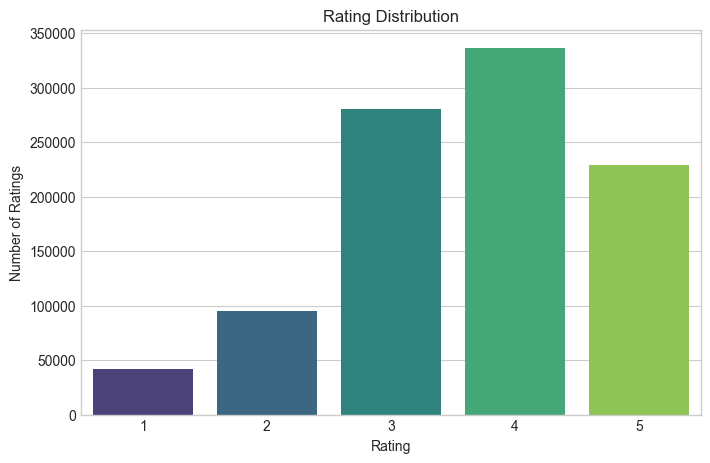

In [17]:
# Task 1.8 - Plot rating distribution
# Shows how users rated movies from 1 to 5

plt.figure(figsize=(8, 5))
sns.countplot(
    data=netflix_df,
    x='rating',
    order=sorted(netflix_df['rating'].dropna().unique()),
    palette='viridis'
)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Ratings')
plt.show()


In [18]:
# Task 1.9 - Create movie-level summary
# 1. Count ratings for each movie
# 2. Calculate average rating for each movie

movie_stats = netflix_df.groupby(['movie_id', 'title']).agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean')
).reset_index()

movie_stats['avg_rating'] = movie_stats['avg_rating'].round(3)

print('Number of movies in sample:', movie_stats.shape[0])
print('Average ratings per movie:', round(movie_stats['rating_count'].mean(), 2))

movie_stats.sort_values(by='rating_count', ascending=False).head(10)


Number of movies in sample: 16090
Average ratings per movie: 61.11


,movie_id,title,rating_count,avg_rating
4811,5317,Miss Congeniality,2333,3.322
13671,15124,Independence Day,2148,3.744
12934,14313,The Patriot,2017,3.808
13742,15205,The Day After Tomorrow,1932,3.443
1723,1905,Pirates of the Caribbean: The Curse of the Bla...,1931,4.188
5695,6287,Pretty Woman,1924,3.885
14817,16377,The Green Mile,1813,4.291
10187,11283,Forrest Gump,1808,4.343
14690,16242,Con Air,1801,3.471
11269,12470,Twister,1753,3.379


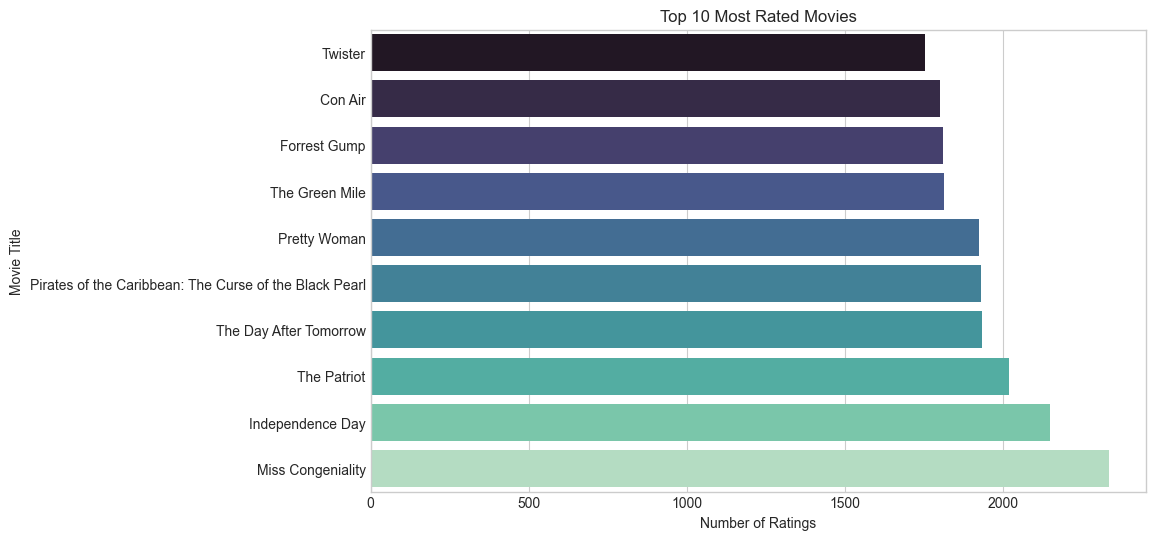

In [19]:
# Task 1.10 - Plot most rated movies
# Shows which movies appear most often in the cleaned sample

top_movies = movie_stats.sort_values(by='rating_count', ascending=False).head(10)
top_movies = top_movies.sort_values(by='rating_count')

plt.figure(figsize=(10, 6))
sns.barplot(data=top_movies, x='rating_count', y='title', palette='mako')
plt.title('Top 10 Most Rated Movies')
plt.xlabel('Number of Ratings')
plt.ylabel('Movie Title')
plt.show()


,movie_id,title,rating_count,avg_rating
13823,15296,Band of Brothers,366,4.557
4610,5103,The Simpsons: Season 5,172,4.564
7008,7742,Six Feet Under: Season 3,159,4.566
5049,5582,Star Wars: Episode V: The Empire Strikes Back,924,4.568
14339,15861,CSI: Season 2,126,4.571
11613,12834,Family Guy: Vol. 2: Season 3,222,4.608
13147,14550,The Shawshank Redemption: Special Edition,1391,4.610
6388,7057,Lord of the Rings: The Two Towers: Extended Ed...,745,4.652
6545,7230,The Lord of the Rings: The Fellowship of the R...,733,4.693
13525,14961,Lord of the Rings: The Return of the King: Ext...,733,4.703


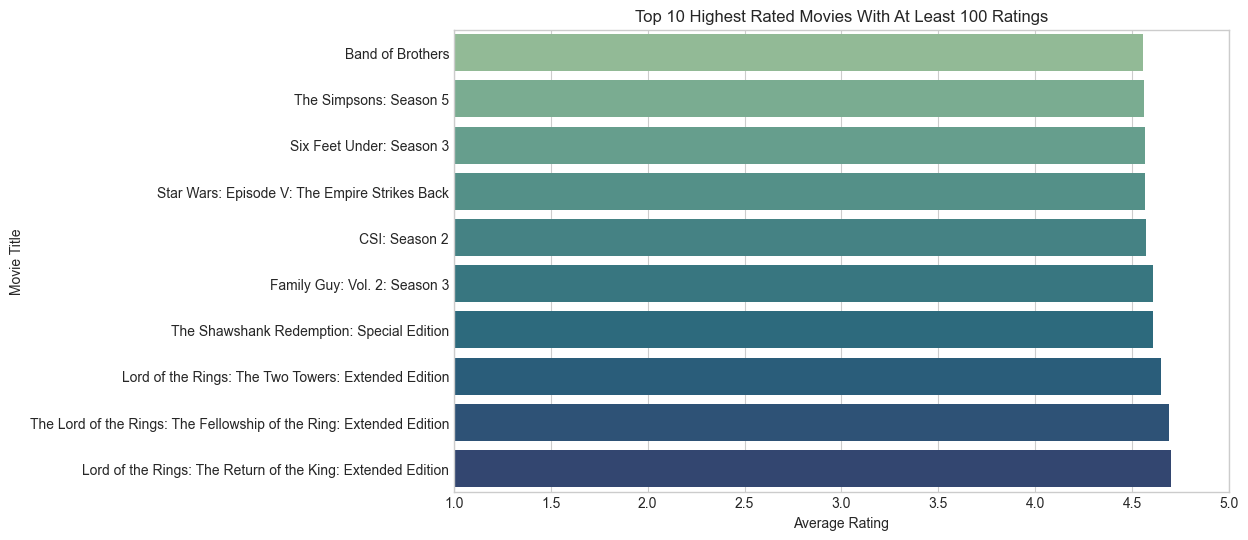

In [20]:
# Task 1.11 - Plot highest rated reliable movies
# Only include movies with at least 100 ratings to avoid misleading averages

reliable_movies = movie_stats[movie_stats['rating_count'] >= 100].copy()

if reliable_movies.empty:
    print('No movies have at least 100 ratings in this sample.')
else:
    top_rated_movies = reliable_movies.sort_values(
        by=['avg_rating', 'rating_count'],
        ascending=False
    ).head(10)
    top_rated_movies = top_rated_movies.sort_values(by='avg_rating')

    display(top_rated_movies)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_rated_movies, x='avg_rating', y='title', palette='crest')
    plt.title('Top 10 Highest Rated Movies With At Least 100 Ratings')
    plt.xlabel('Average Rating')
    plt.ylabel('Movie Title')
    plt.xlim(1, 5)
    plt.show()


Number of users in sample: 4805
Average ratings per user: 204.63
Median ratings per user: 95.0


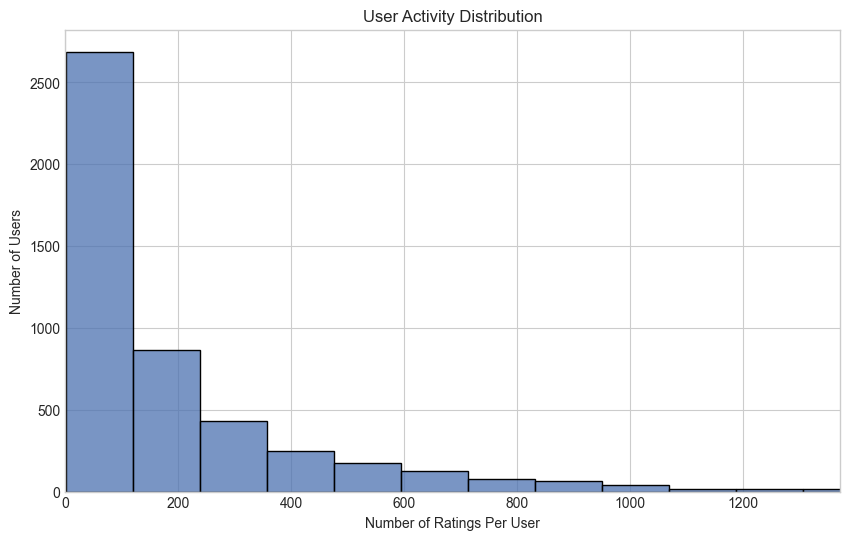

In [21]:
# Task 1.12 - Plot user activity distribution
# Shows how many ratings each user gave in the cleaned sample

user_activity = netflix_df.groupby('user_id')['rating'].count().reset_index(name='rating_count')

print('Number of users in sample:', user_activity.shape[0])
print('Average ratings per user:', round(user_activity['rating_count'].mean(), 2))
print('Median ratings per user:', round(user_activity['rating_count'].median(), 2))

plt.figure(figsize=(10, 6))
sns.histplot(user_activity['rating_count'], bins=50, color='#4C72B0')
plt.title('User Activity Distribution')
plt.xlabel('Number of Ratings Per User')
plt.ylabel('Number of Users')
plt.xlim(0, user_activity['rating_count'].quantile(0.99))
plt.show()


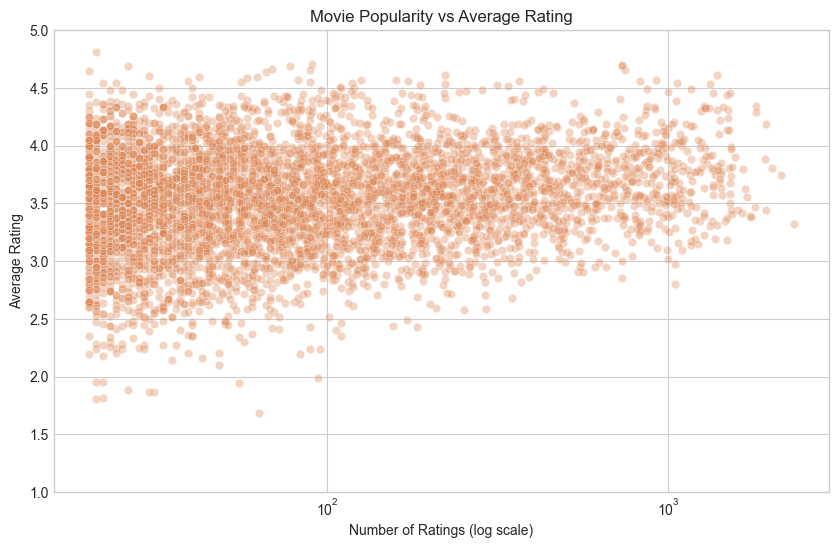

In [22]:
# Task 1.13 - Plot popularity vs average rating
# Shows the relationship between rating count and average movie rating

popularity_rating_df = movie_stats[movie_stats['rating_count'] >= 20].copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=popularity_rating_df,
    x='rating_count',
    y='avg_rating',
    alpha=0.35,
    color='#DD8452'
)
plt.xscale('log')
plt.title('Movie Popularity vs Average Rating')
plt.xlabel('Number of Ratings (log scale)')
plt.ylabel('Average Rating')
plt.ylim(1, 5)
plt.show()


In [23]:
# Task 1.14 - Add genres and age ratings for content analysis
# 1. Load Movies 67 metadata if available
# 2. Merge genres and age_rating with the cleaned sample

from pathlib import Path

metadata_path = Path('movie_metadata.csv')

if metadata_path.exists():
    metadata_df = pd.read_csv(metadata_path)
    metadata_cols = [col for col in ['movie_id', 'genres', 'age_rating'] if col in metadata_df.columns]

    eda_with_metadata = netflix_df.merge(
        metadata_df[metadata_cols].drop_duplicates(subset='movie_id'),
        on='movie_id',
        how='left'
    )

    print('EDA dataframe with metadata shape:', eda_with_metadata.shape)
    print('Metadata columns added:', metadata_cols)
    display(eda_with_metadata.head())
else:
    eda_with_metadata = netflix_df.copy()
    print('movie_metadata.csv was not found, so genre and age rating charts are skipped.')


EDA dataframe with metadata shape: (983241, 6)
Metadata columns added: ['movie_id', 'genres', 'age_rating']


,user_id,movie_id,rating,title,genres,age_rating
0,1196100,1,4,Dinosaur Planet,"Adventure,Science Fiction",Teen
1,99400,1,5,Dinosaur Planet,"Adventure,Science Fiction",Teen
2,2607300,1,3,Dinosaur Planet,"Adventure,Science Fiction",Teen
3,810700,1,5,Dinosaur Planet,"Adventure,Science Fiction",Teen
4,2279000,1,3,Dinosaur Planet,"Adventure,Science Fiction",Teen


,movie_count
genres,
Drama,6555
Comedy,4174
Action,2484
Romance,2417
Thriller,2290
Crime,1696
Adventure,1598
Documentary,1565
Horror,1427


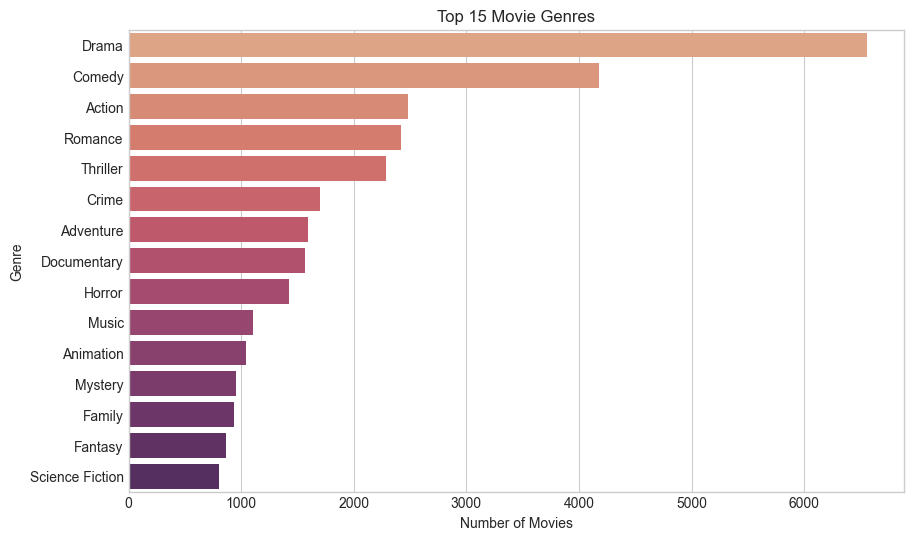

In [24]:
# Task 1.15 - Plot most common genres
# Uses movie metadata to show the most frequent genres in the sample

if 'genres' in eda_with_metadata.columns:
    genre_df = (
        eda_with_metadata[['movie_id', 'genres']]
        .dropna()
        .drop_duplicates()
        .copy()
    )

    genre_df['genres'] = (
        genre_df['genres']
        .astype(str)
        .str.replace('|', ',', regex=False)
        .str.split(',')
    )

    genre_counts = genre_df.explode('genres')
    genre_counts['genres'] = genre_counts['genres'].str.strip()
    genre_counts = genre_counts[genre_counts['genres'] != '']['genres'].value_counts().head(15)

    display(genre_counts.to_frame(name='movie_count'))

    plt.figure(figsize=(10, 6))
    sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='flare')
    plt.title('Top 15 Movie Genres')
    plt.xlabel('Number of Movies')
    plt.ylabel('Genre')
    plt.show()
else:
    print('genres column is not available.')


,movie_count
age_rating,
3+,726
7+,2975
Teen,7445
16+,4790
18+,154


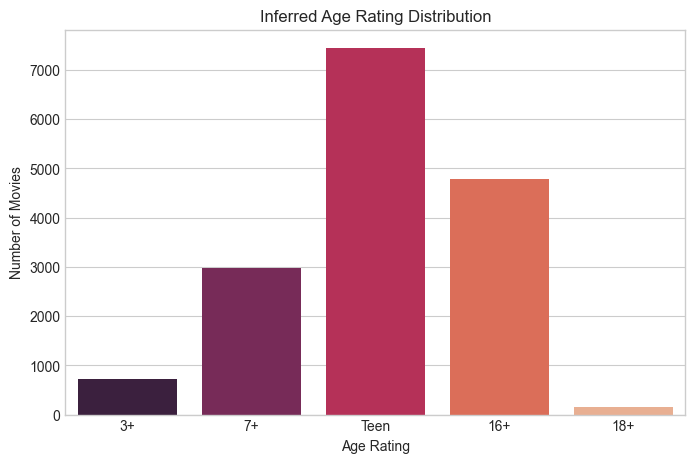

In [25]:
# Task 1.16 - Plot age rating distribution
# Shows the inferred maturity categories used by the website recommender

if 'age_rating' in eda_with_metadata.columns:
    maturity_order = ['3+', '7+', 'Teen', '16+', '18+']

    maturity_counts = (
        eda_with_metadata[['movie_id', 'age_rating']]
        .dropna()
        .drop_duplicates()['age_rating']
        .value_counts()
    )

    maturity_counts = maturity_counts.reindex(
        [rating for rating in maturity_order if rating in maturity_counts.index]
        + [rating for rating in maturity_counts.index if rating not in maturity_order]
    )

    display(maturity_counts.to_frame(name='movie_count'))

    plt.figure(figsize=(8, 5))
    sns.barplot(x=maturity_counts.index, y=maturity_counts.values, palette='rocket')
    plt.title('Inferred Age Rating Distribution')
    plt.xlabel('Age Rating')
    plt.ylabel('Number of Movies')
    plt.show()
else:
    print('age_rating column is not available.')


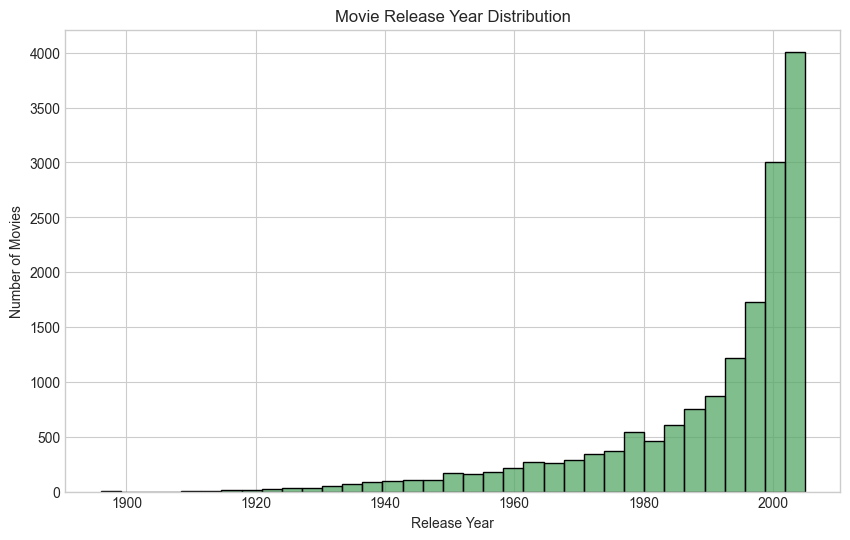

In [26]:
# Task 1.17 - Plot movie release year distribution
# Uses the cleaned merged dataframe before year was dropped for modeling

if 'year' in df.columns:
    movie_years = df[['movie_id', 'title', 'year']].drop_duplicates().dropna(subset=['year']).copy()

    plt.figure(figsize=(10, 6))
    sns.histplot(movie_years['year'], bins=35, color='#55A868')
    plt.title('Movie Release Year Distribution')
    plt.xlabel('Release Year')
    plt.ylabel('Number of Movies')
    plt.show()
else:
    print('year column is not available.')


In [27]:
global_mean = netflix_df['rating'].mean()

user_mean = netflix_df.groupby('user_id')['rating'].mean()
movie_mean = netflix_df.groupby('movie_id')['rating'].mean()

print('Global Mean Rating:', global_mean)

Global Mean Rating: 3.625405165162966


# Model training

In [28]:
X = netflix_df[['user_id', 'movie_id', 'title']]
y = netflix_df['rating']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (983241, 3)
y shape: (983241,)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (786592, 3)
X_test: (196649, 3)
y_train: (786592,)
y_test: (196649,)


In [30]:
# Task 2.3 - Rebuild train and test dataframes
# This keeps your X_train and y_train style, but makes recommender calculations easier

train_df = X_train.copy()
train_df['rating'] = y_train.values

test_df = X_test.copy()
test_df['rating'] = y_test.values

train_df.head()


,user_id,movie_id,title,rating
754020,1742600,14027,Every Which Way But Loose,4
172837,2424300,3385,28 Days Later,3
949211,337400,17169,National Treasure,5
525068,223300,9756,Mr. Deeds,5
761356,634700,14149,Enemy of the State,4


In [31]:
global_mean = train_df['rating'].mean()

user_mean = train_df.groupby('user_id')['rating'].mean()
movie_mean = train_df.groupby('movie_id')['rating'].mean()

user_bias = user_mean - global_mean
movie_bias = movie_mean - global_mean

print('Global Mean Rating:', global_mean)
print('Number of users:', user_bias.shape[0])
print('Number of movies:', movie_bias.shape[0])

Global Mean Rating: 3.6254233452666695
Number of users: 4801
Number of movies: 15601


## Predict

In [32]:
def predict_rating(user_id, movie_id):
    u_bias = user_bias.get(user_id, 0)
    m_bias = movie_bias.get(movie_id, 0)

    pred = global_mean + u_bias + m_bias
    pred = np.clip(pred, 1, 5)

    return pred

In [33]:
test_df['predicted_rating'] = [
    predict_rating(user_id, movie_id)
    for user_id, movie_id in zip(test_df['user_id'], test_df['movie_id'])
]

test_df[['user_id', 'movie_id', 'title', 'rating', 'predicted_rating']].head()


,user_id,movie_id,title,rating,predicted_rating
368888,2357500,6716,Spies Like Us,4,3.622596
4330,2377700,133,Viva La Bam: Season 1,5,4.306015
858622,1214900,15582,Sweet Home Alabama,5,3.763201
724329,332300,13418,Ghostbusters 2,4,2.412756
761448,2371200,14149,Enemy of the State,4,3.793329


# Evaluation

In [34]:
rmse = np.sqrt(mean_squared_error(test_df['rating'], test_df['predicted_rating']))
mae = mean_absolute_error(test_df['rating'], test_df['predicted_rating'])

print('############ Testing Eval #############')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')


############ Testing Eval #############
RMSE: 0.9312
MAE: 0.7272


## Ploting

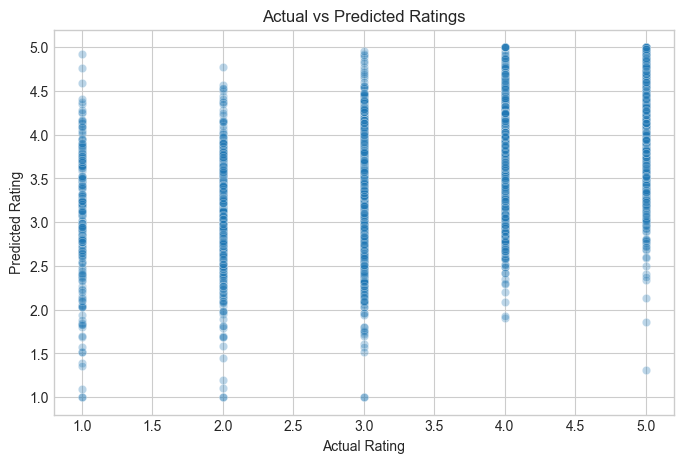

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=test_df['rating'].sample(5000, random_state=42),
    y=test_df['predicted_rating'].sample(5000, random_state=42),
    alpha=0.3
)
plt.title('Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()


# Test unseen data

In [36]:
movie_titles = netflix_df[['movie_id', 'title']].drop_duplicates()

def recommend_movies(user_id, top_n=10):
    watched_movies = netflix_df[netflix_df['user_id'] == user_id]['movie_id'].unique()

    unseen_movies = movie_titles[
        ~movie_titles['movie_id'].isin(watched_movies)
    ].copy()

    unseen_movies['predicted_rating'] = unseen_movies['movie_id'].apply(
        lambda movie_id: predict_rating(user_id, movie_id)
    )

    recommendations = unseen_movies.sort_values(
        by='predicted_rating',
        ascending=False
    ).head(top_n)

    return recommendations


### Sample user

In [37]:
sample_user = netflix_df['user_id'].iloc[0]

print('User ID:', sample_user)
recommend_movies(sample_user, top_n=10)


User ID: 1196100


,movie_id,title,predicted_rating
188219,3661,Fruit of the Vine,4.203148
746297,13802,"Zone of the Enders: Dolores, i",4.203148
528338,9823,Cadfael: The Raven in the Foregate,4.203148
274584,5188,Fafner,4.203148
123969,2442,Godzilla vs. Gigan,4.203148
272779,5165,Yakuza Demon,4.203148
397319,7214,Petey Wheatstraw,4.203148
397306,7211,Area 88 Act #1: The Blue Skies of Betrayal,4.203148
527600,9808,Prodigal Son,4.203148
527599,9807,Neil Young: In Berlin,4.203148


# Save model

In [38]:
# Task 3.6 - Save baseline recommendation model
# The save is skipped only when the website is currently locking the model file.

model_objects = {
    'global_mean': global_mean,
    'user_bias': user_bias,
    'movie_bias': movie_bias,
    'movie_titles': movie_titles
}

try:
    joblib.dump(model_objects, 'netflix_recommendation_model.joblib')
    print('Saved model to netflix_recommendation_model.joblib')
except PermissionError:
    print('Model file is locked by the running website. Training and evaluation continue.')

Saved model to netflix_recommendation_model.joblib


# Hybrid Feedback-Aware SVD Recommender


In [39]:
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from pathlib import Path


In [40]:
# Task 4.2 - Prepare data for SVD matrix factorization
# 1. Keep user_id, movie_id, rating, and title
# 2. Use a smaller sample so training stays practical

svd_df = netflix_df[['user_id', 'movie_id', 'rating', 'title']].dropna().copy()

svd_sample_size = 200000
if svd_df.shape[0] > svd_sample_size:
    svd_df = svd_df.sample(n=svd_sample_size, random_state=42).copy()

svd_df['user_id'] = svd_df['user_id'].astype('int32')
svd_df['movie_id'] = svd_df['movie_id'].astype('int32')
svd_df['rating'] = svd_df['rating'].astype('float32')

print('SVD dataframe shape:', svd_df.shape)
print('Unique users:', svd_df['user_id'].nunique())
print('Unique movies:', svd_df['movie_id'].nunique())
svd_df.head()


SVD dataframe shape: (200000, 4)
Unique users: 4728
Unique movies: 11351


,user_id,movie_id,rating,title
368888,2357500,6716,4.0,Spies Like Us
4330,2377700,133,5.0,Viva La Bam: Season 1
858622,1214900,15582,5.0,Sweet Home Alabama
724329,332300,13418,4.0,Ghostbusters 2
761448,2371200,14149,4.0,Enemy of the State


In [41]:
# Task 4.3 - Split SVD train and test data
# 1. Define X and y
# 2. Split into train and test sets

svd_X = svd_df[['user_id', 'movie_id', 'title']]
svd_y = svd_df['rating']

svd_X_train, svd_X_test, svd_y_train, svd_y_test = train_test_split(
    svd_X,
    svd_y,
    test_size=0.20,
    random_state=42
)

svd_train_df = svd_X_train.copy()
svd_train_df['rating'] = svd_y_train.values

svd_test_df = svd_X_test.copy()
svd_test_df['rating'] = svd_y_test.values

print('SVD train shape:', svd_train_df.shape)
print('SVD test shape:', svd_test_df.shape)


SVD train shape: (160000, 4)
SVD test shape: (40000, 4)


In [42]:
# Task 4.4 - Encode users and movies
# 1. Encode user_id into user_idx
# 2. Encode movie_id into movie_idx
# 3. Build lookup dictionaries for fast prediction

user_encoder_svd = LabelEncoder()
movie_encoder_svd = LabelEncoder()

user_encoder_svd.fit(svd_df['user_id'])
movie_encoder_svd.fit(svd_df['movie_id'])

svd_train_df['user_idx'] = user_encoder_svd.transform(svd_train_df['user_id'])
svd_train_df['movie_idx'] = movie_encoder_svd.transform(svd_train_df['movie_id'])

svd_test_df['user_idx'] = user_encoder_svd.transform(svd_test_df['user_id'])
svd_test_df['movie_idx'] = movie_encoder_svd.transform(svd_test_df['movie_id'])

n_users = len(user_encoder_svd.classes_)
n_movies = len(movie_encoder_svd.classes_)

user_id_to_idx_svd = {
    int(user_id): int(idx)
    for idx, user_id in enumerate(user_encoder_svd.classes_)
}

movie_id_to_idx_svd = {
    int(movie_id): int(idx)
    for idx, movie_id in enumerate(movie_encoder_svd.classes_)
}

user_id_set_svd = set(user_id_to_idx_svd.keys())
movie_id_set_svd = set(movie_id_to_idx_svd.keys())

print('Encoded users:', n_users)
print('Encoded movies:', n_movies)


Encoded users: 4728
Encoded movies: 11351


In [43]:
# Task 4.5 - Train SVD matrix factorization model
# 1. Build sparse user-movie rating matrix
# 2. Center ratings around the global mean
# 3. Train TruncatedSVD

global_mean_svd = svd_train_df['rating'].mean()

rating_matrix = csr_matrix(
    (
        svd_train_df['rating'] - global_mean_svd,
        (svd_train_df['user_idx'], svd_train_df['movie_idx'])
    ),
    shape=(n_users, n_movies)
)

svdModel = TruncatedSVD(n_components=30, random_state=42)
user_factors = svdModel.fit_transform(rating_matrix)
movie_factors = svdModel.components_.T

print('User factors shape:', user_factors.shape)
print('Movie factors shape:', movie_factors.shape)
print('Explained variance:', svdModel.explained_variance_ratio_.sum())


User factors shape: (4728, 30)
Movie factors shape: (11351, 30)
Explained variance: 0.11193994


In [44]:
# Task 4.6 - Create SVD prediction function
# Predict rating using user and movie latent vectors


def predict_svd_rating(user_id, movie_id):
    user_id = int(user_id)
    movie_id = int(movie_id)

    if user_id not in user_id_set_svd:
        return global_mean_svd
    if movie_id not in movie_id_set_svd:
        return global_mean_svd

    user_idx = user_id_to_idx_svd[user_id]
    movie_idx = movie_id_to_idx_svd[movie_id]

    pred = global_mean_svd + np.dot(user_factors[user_idx], movie_factors[movie_idx])
    pred = np.clip(pred, 1, 5)

    return pred


In [45]:
# Task 4.7 - Predict and evaluate SVD model
# Display: RMSE and MAE on SVD test data

svd_test_df['svd_predicted_rating'] = [
    predict_svd_rating(user_id, movie_id)
    for user_id, movie_id in zip(svd_test_df['user_id'], svd_test_df['movie_id'])
]

svd_rmse = np.sqrt(mean_squared_error(svd_test_df['rating'], svd_test_df['svd_predicted_rating']))
svd_mae = mean_absolute_error(svd_test_df['rating'], svd_test_df['svd_predicted_rating'])

print('############ SVD Testing Eval #############')
print(f'RMSE: {svd_rmse:.4f}')
print(f'MAE: {svd_mae:.4f}')

svd_test_df[['user_id', 'movie_id', 'title', 'rating', 'svd_predicted_rating']].head()


############ SVD Testing Eval #############
RMSE: 1.0608
MAE: 0.8840


,user_id,movie_id,title,rating,svd_predicted_rating
841548,593400,15289,Joe,5.0,3.623151
262721,1099100,4996,Gone in 60 Seconds,4.0,3.577743
839077,583000,15205,The Day After Tomorrow,5.0,3.553377
556826,203800,10378,The Bone Collector,2.0,3.605476
13126,177700,295,Ace Ventura: When Nature Calls,5.0,3.646754


############ Recommender Model Comparison #############


,model,RMSE,MAE
0,Global Average Baseline,1.0717,0.896
1,SVD Matrix Factorization,1.0608,0.884


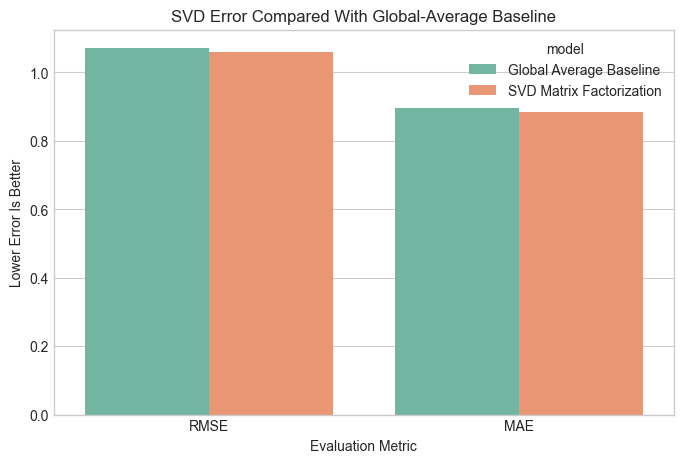

In [46]:
# Task 4.7.a - Compare SVD with a global-average baseline
# 1. Predict every test rating with the training average
# 2. Compare baseline error with SVD error

svd_test_df['baseline_predicted_rating'] = global_mean_svd

baseline_rmse = np.sqrt(mean_squared_error(
    svd_test_df['rating'],
    svd_test_df['baseline_predicted_rating']
))
baseline_mae = mean_absolute_error(
    svd_test_df['rating'],
    svd_test_df['baseline_predicted_rating']
)

svd_comparison = pd.DataFrame({
    'model': ['Global Average Baseline', 'SVD Matrix Factorization'],
    'RMSE': [baseline_rmse, svd_rmse],
    'MAE': [baseline_mae, svd_mae]
}).round(4)

print('############ Recommender Model Comparison #############')
display(svd_comparison)

plt.figure(figsize=(8, 5))
sns.barplot(data=svd_comparison.melt(id_vars='model', var_name='metric', value_name='error'),
            x='metric', y='error', hue='model', palette='Set2')
plt.title('SVD Error Compared With Global-Average Baseline')
plt.xlabel('Evaluation Metric')
plt.ylabel('Lower Error Is Better')
plt.show()

In [47]:
# Task 4.7.b - Inspect SVD prediction errors
# Shows actual ratings, predicted ratings, and the largest absolute errors

svd_test_df['absolute_error'] = (
    svd_test_df['rating'] - svd_test_df['svd_predicted_rating']
).abs()

svd_prediction_examples = svd_test_df[
    ['user_id', 'movie_id', 'title', 'rating', 'svd_predicted_rating', 'absolute_error']
].copy()

svd_prediction_examples['svd_predicted_rating'] = svd_prediction_examples['svd_predicted_rating'].round(2)
svd_prediction_examples['absolute_error'] = svd_prediction_examples['absolute_error'].round(2)

print('Sample SVD predictions:')
display(svd_prediction_examples.sample(min(10, len(svd_prediction_examples)), random_state=42))

print('Largest SVD prediction errors:')
display(svd_prediction_examples.sort_values('absolute_error', ascending=False).head(10))

Sample SVD predictions:


,user_id,movie_id,title,rating,svd_predicted_rating,absolute_error
278346,804300,5257,The Secret Lives of Dentists,2.0,3.61,1.61
202576,2614700,3921,101 Dalmatians II: Patch's London Adventure,3.0,3.63,0.63
47360,1740800,985,The Mummy,3.0,3.57,0.57
116548,625200,2326,The Laramie Project,4.0,3.63,0.37
409942,361000,7399,Phenomenon,3.0,3.63,0.63
17003,1695600,330,Wild Things,5.0,3.63,1.37
56210,1086400,1145,The Wedding Planner,4.0,3.62,0.38
714403,511700,13219,Jane Eyre,4.0,3.63,0.37
511410,100400,9498,Lewis Black: Black on Broadway,1.0,3.63,2.63
534508,415100,9960,Die Hard,3.0,3.59,0.59


Largest SVD prediction errors:


,user_id,movie_id,title,rating,svd_predicted_rating,absolute_error
109014,1327900,2152,What Women Want,1.0,5.00,4.00
655476,414800,12232,Lost in Translation,1.0,4.17,3.17
655275,2532100,12232,Lost in Translation,1.0,4.05,3.05
632003,530000,11805,The Big Bounce,1.0,3.98,2.98
343735,1098900,6287,Pretty Woman,1.0,3.90,2.90
524374,1952500,9756,Mr. Deeds,1.0,3.88,2.88
589029,2301000,11064,Pulp Fiction,1.0,3.87,2.87
476625,1490800,8782,The Royal Tenenbaums,1.0,3.87,2.87
55677,599100,1145,The Wedding Planner,1.0,3.85,2.85
901886,95300,16377,The Green Mile,1.0,3.84,2.84


In [48]:
# Task 4.8 - Generate SVD candidate recommendations
# 1. Remove movies the user already rated
# 2. Score unseen movies using SVD
# 3. Return top candidate movies

svd_movie_titles = svd_df[['movie_id', 'title']].drop_duplicates().copy()

movie_id_set_svd = set(movie_encoder_svd.classes_)


def get_svd_recommendations(user_id, top_n=20):
    watched_movies = svd_df[svd_df['user_id'] == user_id]['movie_id'].unique()

    candidate_movies = svd_movie_titles[
        ~svd_movie_titles['movie_id'].isin(watched_movies)
    ].copy()

    candidate_movies = candidate_movies[
        candidate_movies['movie_id'].isin(movie_id_set_svd)
    ].copy()

    candidate_movies['svd_score'] = candidate_movies['movie_id'].apply(
        lambda movie_id: predict_svd_rating(user_id, movie_id)
    )

    return candidate_movies.sort_values(by='svd_score', ascending=False).head(top_n)


In [49]:
# Task 4.9 - Create feedback table structure
# This simulates feedback that will later come from the website database

feedback_df = pd.DataFrame(columns=[
    'user_id',
    'movie_id',
    'title',
    'rating',
    'review_text',
    'sentiment_label'
])

feedback_df.head()


,user_id,movie_id,title,rating,review_text,sentiment_label


In [50]:
# Task 4.10 - Create feedback helper functions
# 1. Convert rating to sentiment
# 2. Add feedback row


def rating_to_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'


def add_user_feedback(feedback_df, user_id, movie_id, rating, review_text):
    movie_title = svd_movie_titles[svd_movie_titles['movie_id'] == movie_id]['title'].values[0]
    sentiment_label = rating_to_sentiment(rating)

    new_feedback = pd.DataFrame({
        'user_id': [user_id],
        'movie_id': [movie_id],
        'title': [movie_title],
        'rating': [rating],
        'review_text': [review_text],
        'sentiment_label': [sentiment_label]
    })

    feedback_df = pd.concat([feedback_df, new_feedback], ignore_index=True)
    return feedback_df


In [51]:
# Task 4.11 - Re-rank recommendations using user feedback
# 1. Exclude movies already reviewed by the user
# 2. Boost movies that received good feedback
# 3. Adjust recommendations using the user's average feedback rating


def rerank_with_feedback(user_id, candidate_recommendations, feedback_df, top_n=10):
    recs = candidate_recommendations.copy()

    if feedback_df.empty:
        recs['final_score'] = recs['svd_score']
        return recs.sort_values(by='final_score', ascending=False).head(top_n)

    user_feedback = feedback_df[feedback_df['user_id'] == user_id]
    reviewed_movies = user_feedback['movie_id'].unique()

    recs = recs[~recs['movie_id'].isin(reviewed_movies)].copy()

    movie_feedback_mean = feedback_df.groupby('movie_id')['rating'].mean()
    user_feedback_bias = 0

    if not user_feedback.empty:
        user_feedback_bias = user_feedback['rating'].mean() - 3

    recs['feedback_movie_score'] = recs['movie_id'].map(movie_feedback_mean).fillna(3)
    recs['final_score'] = (
        recs['svd_score']
        + 0.25 * (recs['feedback_movie_score'] - 3)
        + 0.10 * user_feedback_bias
    )

    return recs.sort_values(by='final_score', ascending=False).head(top_n)


In [52]:
# Task 4.12 - Test hybrid recommendations
# Generate SVD candidates, then re-rank them with feedback

sample_user = svd_df['user_id'].iloc[0]

candidate_recommendations = get_svd_recommendations(sample_user, top_n=20)
hybrid_recommendations = rerank_with_feedback(
    sample_user,
    candidate_recommendations,
    feedback_df,
    top_n=10
)

print('Sample user:', sample_user)
hybrid_recommendations


Sample user: 2357500


,movie_id,title,svd_score,final_score
94942,1905,Pirates of the Caribbean: The Curse of the Bla...,3.959832,3.959832
262645,4996,Gone in 60 Seconds,3.876669,3.876669
741617,13728,Gladiator,3.833337,3.833337
935163,16954,Indiana Jones and the Last Crusade,3.807790,3.807790
606811,11283,Forrest Gump,3.790196,3.790196
772865,14313,The Patriot,3.789613,3.789613
205397,3938,Shrek 2,3.787830,3.787830
767584,14240,Lord of the Rings: The Return of the King,3.787672,3.787672
798088,14621,Shrek (Full-screen),3.787000,3.787000
858622,15582,Sweet Home Alabama,3.786251,3.786251


# NLP Sentiment Model From ACL IMDb Reviews


In [53]:
# Task 5.1 - Load ACL IMDb dataset paths
# Dataset folder: aclImdb/train and aclImdb/test

imdb_path = Path('aclImdb')

print('ACL IMDb path exists:', imdb_path.exists())
print('Train positive path exists:', (imdb_path / 'train' / 'pos').exists())
print('Train negative path exists:', (imdb_path / 'train' / 'neg').exists())


ACL IMDb path exists: True
Train positive path exists: True
Train negative path exists: True


In [54]:
# Task 5.2 - Create function to load IMDb reviews
# 1. Read positive reviews
# 2. Read negative reviews
# 3. Return dataframe with review_text and sentiment_label


def load_imdb_split(split_name, max_files_per_class=None):
    rows = []

    for folder_name, sentiment_label in [('pos', 'Positive'), ('neg', 'Negative')]:
        folder_path = imdb_path / split_name / folder_name
        files = sorted(folder_path.glob('*.txt'))

        if max_files_per_class is not None:
            files = files[:max_files_per_class]

        for file_path in files:
            review_text = file_path.read_text(encoding='utf-8', errors='ignore')
            rows.append({
                'review_text': review_text,
                'sentiment_label': sentiment_label,
                'split': split_name
            })

    return pd.DataFrame(rows)


In [55]:
# Task 5.3 - Load train and test reviews
# Change max_files_per_class to None if you want to train on the full ACL IMDb dataset

imdb_train_df = load_imdb_split('train', max_files_per_class=5000)
imdb_test_df = load_imdb_split('test', max_files_per_class=2000)

print('IMDb train shape:', imdb_train_df.shape)
print('IMDb test shape:', imdb_test_df.shape)
print()
print('Training label distribution:')
print(imdb_train_df['sentiment_label'].value_counts())

imdb_train_df.head()


IMDb train shape: (10000, 3)
IMDb test shape: (4000, 3)

Training label distribution:
sentiment_label
Positive    5000
Negative    5000
Name: count, dtype: int64


,review_text,sentiment_label,split
0,Bromwell High is a cartoon comedy. It ran at t...,Positive,train
1,Homelessness (or Houselessness as George Carli...,Positive,train
2,Brilliant over-acting by Lesley Ann Warren. Be...,Positive,train
3,This is easily the most underrated film inn th...,Positive,train
4,This is not the typical Mel Brooks film. It wa...,Positive,train


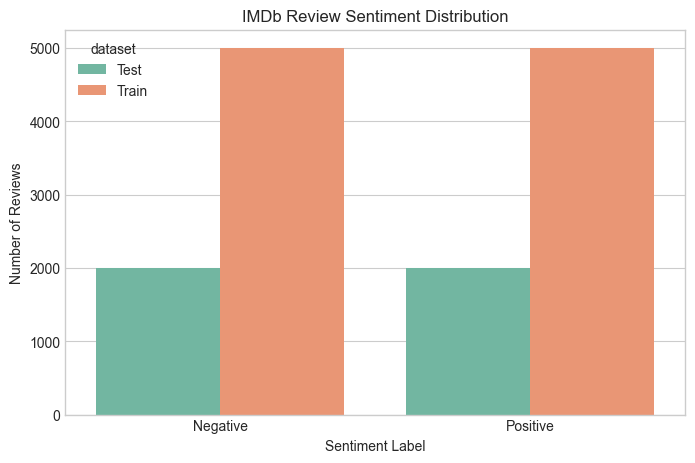

In [56]:
# Task 5.3.a - Plot IMDb sentiment class distribution
# Shows whether the NLP training and testing data are balanced

nlp_label_counts = pd.concat([
    imdb_train_df.assign(dataset='Train'),
    imdb_test_df.assign(dataset='Test')
]).groupby(['dataset', 'sentiment_label']).size().reset_index(name='review_count')

plt.figure(figsize=(8, 5))
sns.barplot(data=nlp_label_counts, x='sentiment_label', y='review_count', hue='dataset',
            order=['Negative', 'Positive'], palette='Set2')
plt.title('IMDb Review Sentiment Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Number of Reviews')
plt.show()

In [57]:
# Task 5.4 - Define NLP X and y
# 1. Review text is X
# 2. Sentiment label is y

X_nlp_train = imdb_train_df['review_text']
y_nlp_train = imdb_train_df['sentiment_label']

X_nlp_test = imdb_test_df['review_text']
y_nlp_test = imdb_test_df['sentiment_label']

print('X_nlp_train:', X_nlp_train.shape)
print('X_nlp_test:', X_nlp_test.shape)


X_nlp_train: (10000,)
X_nlp_test: (4000,)


In [58]:
# Task 5.5 - Train NLP sentiment model
# 1. Tokenize reviews with TF-IDF
# 2. Train Logistic Regression classifier

nlpModel = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2,
        max_features=50000
    )),
    ('lgModel', LogisticRegression(max_iter=1000, random_state=42))
])

nlpModel.fit(X_nlp_train, y_nlp_train)

print('NLP model trained successfully')


NLP model trained successfully


In [59]:
# Task 5.6 - Evaluate NLP sentiment model
# Display: accuracy and classification report

y_nlp_pred = nlpModel.predict(X_nlp_test)

print('############ NLP Testing Eval #############')
print(f"Accuracy: {accuracy_score(y_nlp_test, y_nlp_pred):.4f}")
print(classification_report(y_nlp_test, y_nlp_pred))


############ NLP Testing Eval #############
Accuracy: 0.8852
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89      2000
    Positive       0.89      0.88      0.88      2000

    accuracy                           0.89      4000
   macro avg       0.89      0.89      0.89      4000
weighted avg       0.89      0.89      0.89      4000



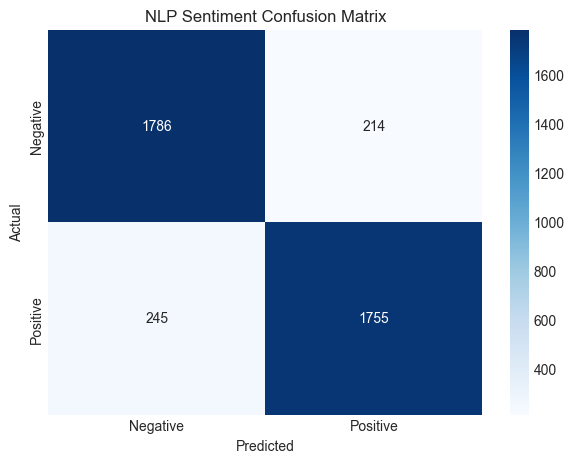

In [60]:
# Task 5.7 - Plot NLP confusion matrix
# Display: positive vs negative classification performance

nlp_labels = ['Negative', 'Positive']
nlp_cm = confusion_matrix(y_nlp_test, y_nlp_pred, labels=nlp_labels)

plt.figure(figsize=(7, 5))
sns.heatmap(nlp_cm, annot=True, fmt='d', cmap='Blues', xticklabels=nlp_labels, yticklabels=nlp_labels)
plt.title('NLP Sentiment Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [61]:
# Task 5.7.a - Inspect correct and incorrect NLP predictions
# Helps explain where TF-IDF + Logistic Regression succeeds and fails

nlp_results = pd.DataFrame({
    'review_text': X_nlp_test.values,
    'actual_sentiment': y_nlp_test.values,
    'predicted_sentiment': y_nlp_pred
})

nlp_results['is_correct'] = (
    nlp_results['actual_sentiment'] == nlp_results['predicted_sentiment']
)

print('Correct prediction examples:')
display(nlp_results[nlp_results['is_correct']].sample(
    min(3, nlp_results['is_correct'].sum()), random_state=42
)[['review_text', 'actual_sentiment', 'predicted_sentiment']])

print('Incorrect prediction examples:')
wrong_predictions = nlp_results[~nlp_results['is_correct']]
if wrong_predictions.empty:
    print('No incorrect predictions were found in this test run.')
else:
    display(wrong_predictions.sample(
        min(3, len(wrong_predictions)), random_state=42
    )[['review_text', 'actual_sentiment', 'predicted_sentiment']])

Correct prediction examples:


,review_text,actual_sentiment,predicted_sentiment
814,Kramer vs. Kramer is the story of a marital br...,Positive,Positive
315,"An obsessive love story, where the characters ...",Positive,Positive
1658,Joline (Heather Graham) married Carl (Luke Wil...,Positive,Positive


Incorrect prediction examples:


,review_text,actual_sentiment,predicted_sentiment
1210,OK. A warning for anyone out there who is a pa...,Positive,Negative
252,It's a horror story alright. But perhaps not a...,Positive,Negative
1642,Yesterday I finally satisfied my curiosity and...,Positive,Negative


In [62]:
# Task 5.8 - Test NLP model on new user review
# This is the same type of review the website user will write after watching a movie

new_review = pd.Series([
    'I felt excited while watching it and the ending was very satisfying.',
    'I was bored and the movie felt too slow for me.'
])

new_review_predictions = nlpModel.predict(new_review)

display(pd.DataFrame({
    'review_text': new_review,
    'predicted_sentiment': new_review_predictions
}))


,review_text,predicted_sentiment
0,I felt excited while watching it and the endin...,Negative
1,I was bored and the movie felt too slow for me.,Negative


In [63]:
# Task 5.9 - Save NLP sentiment model
# The website can load this model to classify written user feedback.

try:
    joblib.dump(nlpModel, 'netflix_review_nlp_model.joblib', compress=3)
    print('Saved NLP model to netflix_review_nlp_model.joblib')
except PermissionError:
    print('NLP model file is locked by the running website. Training and evaluation continue.')

Saved NLP model to netflix_review_nlp_model.joblib


# Save Final Hybrid Model


In [64]:
# Task 6.1 - Save hybrid SVD feedback-aware recommender
# 1. Save SVD movie factors for feedback-based user profiles
# 2. Save movie bias for cold-start recommendations
# 3. Save movie titles for the website

svd_movie_bias = svd_train_df.groupby('movie_id')['rating'].mean() - global_mean_svd
svd_user_bias = svd_train_df.groupby('user_id')['rating'].mean() - global_mean_svd

hybrid_model_objects = {
    'model_type': 'hybrid_svd_feedback_reranker',
    'global_mean': float(global_mean_svd),
    'movie_titles': svd_movie_titles,
    'movie_bias': svd_movie_bias,
    'user_bias': svd_user_bias,
    'svd_model': svdModel,
    'movie_factors': movie_factors.astype('float32'),
    'movie_id_to_idx': movie_id_to_idx_svd,
    'n_components': 30
}

try:
    joblib.dump(hybrid_model_objects, 'netflix_recommendation_model.joblib', compress=3)
    print('Saved hybrid recommender to netflix_recommendation_model.joblib')
    print('Model type:', hybrid_model_objects['model_type'])
except PermissionError:
    print('Model file is locked by the running website. Training and evaluation continue.')

Saved hybrid recommender to netflix_recommendation_model.joblib
Model type: hybrid_svd_feedback_reranker


In [65]:
# Final Note
# Main implemented model: SVD / Matrix Factorization + feedback re-ranking
# NLP model: TF-IDF + Logistic Regression trained on ACL IMDb reviews
# Future work: Deep Reinforcement Learning or LightGCN with feedback signals

print('Final recommendation model: netflix_recommendation_model.joblib')
print('Final NLP feedback model: netflix_review_nlp_model.joblib')


Final recommendation model: netflix_recommendation_model.joblib
Final NLP feedback model: netflix_review_nlp_model.joblib
